# BaliNavi Data Cleaning, Preprocessing, EDA, and Quality Validation

Notebook ini memproses dataset raw BaliNavi menjadi dataset cleaned dan model-ready sesuai `docs/DATASET_CONTRACT.md` dan `docs/DATA_QUALITY_RULES.md`.

Output utama:
- `data/processed/bali_destinations.csv`
- `data/final/bali_destinations.csv`

Notebook ini tidak mengubah kode pipeline `src/`; logic di sini dapat dipindahkan ke `src/preprocessing/preprocess.py` dan `src/features/build_features.py` setelah tervalidasi.

## Kesesuaian dengan Kriteria Minggu 2

| Kriteria | Status di notebook | Bagian terkait |
|---|---|---|
| Data cleaning | Terpenuhi: trim teks, drop nama/lokasi kosong, validasi URL, hapus duplikat | Bagian 4 |
| Imputation | Terpenuhi: field opsional yang tidak tersedia di raw diisi `null`, harga/rating/review invalid punya fallback aman, district kosong di-fallback ke `Unknown` | Bagian 3-4 |
| Preprocessing | Terpenuhi: rename kolom raw ke kontrak proyek, pembentukan schema processed, dan penataan tipe data | Bagian 4 |
| Normalisasi harga | Terpenuhi: harga diparse ke integer IDR, non-negatif, `is_free`, `price_level`, dan `budget_tiers` | Bagian 3-5 |
| Normalisasi kategori | Terpenuhi: `kategori` dipetakan ke `category_main`, `detail_category`, dan `sub_category` | Bagian 3-5 |
| Normalisasi lokasi | Terpenuhi: prefix `Kabupaten`/`Kota` dibersihkan, title case, koordinat divalidasi ke batas Bali | Bagian 3-5 |
| Normalisasi rating | Terpenuhi: rating diparse numeric dan clamp ke 0.0-5.0 | Bagian 3-4 |
| EDA awal | Terpenuhi: missingness, duplikat, distribusi kategori/lokasi/harga/rating/review, outlier, dan koordinat | Bagian 2 dan 6 |
| Feature engineering | Terpenuhi: `content_text` diperkaya dengan keyword enrichment, price/rating tokens, dan region tokens; `popularity_score`, `budget_tiers`, `recommendation_eligible` | Bagian 3, 5 |
| Validasi kualitas dataset | Terpenuhi: quality summary, `data_quality_score`, daftar issue, dan assert validasi kontrak | Bagian 5, 7, 9 |

Dengan cakupan tersebut, notebook ini sudah memenuhi deliverable: clean dataset v1, notebook EDA, fitur awal destinasi, dan daftar issue kualitas data.

## 1. Setup

Bagian ini menyiapkan environment analisis agar notebook dapat dijalankan ulang dari root project maupun dari folder `notebooks/`. Path input dan output dibuat eksplisit, dependency utama di-import, dan konstanta kategori resmi diambil dari `src/utils/constants.py` supaya hasil notebook konsisten dengan kontrak aplikasi.

In [1]:
from __future__ import annotations

import math
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:  # Fallback if this notebook is smoke-tested as plain Python.
    display = print

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

from src.utils.constants import SUPPORTED_CATEGORIES, SUPPORTED_SUB_CATEGORIES

RAW_PATH = ROOT / "data" / "raw" / "bali_tourist_destination_with_harga_full_1452.csv"
PROCESSED_PATH = ROOT / "data" / "processed" / "bali_destinations.csv"
FINAL_PATH = ROOT / "data" / "final" / "bali_destinations.csv"

PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
FINAL_PATH.parent.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

print(f"Project root: {ROOT}")
print(f"Raw dataset: {RAW_PATH}")

Project root: d:\Pijak\balinavi-smart-travel
Raw dataset: d:\Pijak\balinavi-smart-travel\data\raw\bali_tourist_destination_with_harga_full_1452.csv


## 2. Load Raw Dataset and Audit Schema

Bagian ini melakukan EDA awal terhadap file raw. Tujuannya adalah memahami ukuran dataset, tipe data, jumlah missing value, jumlah nilai unik, blank string, contoh data, serta duplikat awal berdasarkan nama destinasi dan lokasi. Hasil audit ini menjadi baseline sebelum data dibersihkan.

In [2]:
raw_df = pd.read_csv(RAW_PATH)

raw_summary = pd.DataFrame(
    {
        "metric": ["rows", "columns", "duplicate_name_location", "file_size_mb"],
        "value": [
            len(raw_df),
            raw_df.shape[1],
            raw_df.duplicated(subset=["nama_tempat_wisata", "kabupaten_kota"]).sum(),
            round(RAW_PATH.stat().st_size / (1024 * 1024), 2),
        ],
    }
)

schema_audit = pd.DataFrame(
    {
        "column": raw_df.columns,
        "dtype": [str(dtype) for dtype in raw_df.dtypes],
        "missing_count": raw_df.isna().sum().to_numpy(),
        "missing_pct": (raw_df.isna().mean() * 100).round(2).to_numpy(),
        "unique_count": raw_df.nunique(dropna=True).to_numpy(),
    }
)

text_columns = [
    col
    for col in raw_df.columns
    if pd.api.types.is_object_dtype(raw_df[col]) or pd.api.types.is_string_dtype(raw_df[col])
]
blank_counts = {
    col: raw_df[col].astype("string").str.strip().eq("").fillna(False).sum()
    for col in text_columns
}
blank_audit = pd.DataFrame(
    {"column": list(blank_counts), "blank_string_count": list(blank_counts.values())}
)

display(raw_summary)
display(schema_audit)
display(blank_audit)
display(raw_df.head())

,metric,value
0,rows,1452.0
1,columns,12.0
2,duplicate_name_location,9.0
3,file_size_mb,0.7


,column,dtype,missing_count,missing_pct,unique_count
0,id_tempat,str,0,0.00,1452
1,nama_tempat_wisata,str,0,0.00,1437
2,kategori,str,0,0.00,4
3,kecamatan,str,0,0.00,56
4,kabupaten_kota,str,0,0.00,9
5,harga_destinasi,int64,0,0.00,27
6,rating,float64,0,0.00,23
7,jumlah_rating,int64,0,0.00,671
8,latitude,float64,0,0.00,1439
9,longitude,float64,0,0.00,1440


,column,blank_string_count
0,id_tempat,0
1,nama_tempat_wisata,0
2,kategori,0
3,kecamatan,0
4,kabupaten_kota,0
5,link_google_maps,0
6,link_gambar,0


,id_tempat,nama_tempat_wisata,kategori,kecamatan,kabupaten_kota,harga_destinasi,rating,jumlah_rating,latitude,longitude,link_google_maps,link_gambar
0,BL0101001,Patung Titi Banda,Umum,Denpasar Barat,Kota Denpasar,0,4.6,1941,-8.649292,115.255043,https://www.google.com/maps/place/Patung+Titi+...,https://lh3.googleusercontent.com/gps-cs-s/AHV...
1,BL0101002,Uma.palak.(parkir.2),Rekreasi,Denpasar Barat,Kota Denpasar,0,4.8,83,-8.617877,115.212975,https://www.google.com/maps/place/Uma.palak.%2...,https://lh3.googleusercontent.com/p/AF1QipOS1G...
2,BL0101003,Tukad Bindu Park,Rekreasi,Denpasar Barat,Kota Denpasar,0,4.5,1180,-8.643791,115.235812,https://www.google.com/maps/place/Tukad+Bindu+...,https://lh3.googleusercontent.com/gps-cs-s/AHV...
3,BL0101004,Pantai Padang Galak,Alam,Denpasar Barat,Kota Denpasar,0,4.6,486,-8.661138,115.263301,https://www.google.com/maps/place/Pantai+Padan...,https://lh3.googleusercontent.com/gps-cs-s/AHV...
4,BL0101005,Museum Le Mayeur,Budaya,Denpasar Barat,Kota Denpasar,10000,4.1,679,-8.674877,115.263678,https://www.google.com/maps/place/Museum+Le+Ma...,https://lh3.googleusercontent.com/gps-cs-s/AHV...


## 3. Cleaning and Normalization Helpers

Bagian ini mendefinisikan fungsi reusable untuk cleaning, imputation, normalisasi, dan enrichment. Fungsi-fungsi ini menangani parsing harga, rating, review count, kategori, sub-kategori, URL, koordinat Bali, text normalization, dan pembentukan `content_text` yang diperkaya. Sub-kategori di-infer dari kata kunci nama destinasi karena dataset raw tidak memiliki detail kategori seperti `Pantai` atau `Pura`. Content text enrichment menambahkan keyword domain per sub-kategori, price/rating signal tokens, dan geographic region tokens untuk meningkatkan discriminative power TF-IDF.

In [3]:
CATEGORY_MAP = {
    "alam": "nature",
    "budaya": "culture",
    "rekreasi": "recreation",
    "umum": "general",
}

DETAIL_SUBCATEGORY_MAP = {
    "pantai": "beach",
    "pura": "temple",
    "candi": "temple",
    "air terjun": "waterfall",
    "hutan": "forest",
    "gunung": "mountain",
    "bukit": "mountain",
    "museum": "museum",
    "desa": "village",
    "desa wisata": "village",
    "waterpark": "waterpark",
    "taman air": "waterpark",
    "landmark": "landmark",
    "monumen": "landmark",
    "tugu": "landmark",
    "belanja": "shopping",
    "pasar": "shopping",
    "mall": "shopping",
}

SUBCATEGORY_PATTERNS = [
    ("waterfall", [r"\bair\s+terjun\b", r"\bwaterfall\b", r"\btegenungan\b", r"\bgitgit\b", r"\bsekumpul\b"]),
    ("waterpark", [r"\bwater\s*park\b", r"\bwaterpark\b", r"\btaman\s+air\b"]),
    ("beach", [r"\bpantai\b", r"\bbeach\b", r"\bsanur\b", r"\bkuta\b", r"\bnusa\s+dua\b"]),
    ("temple", [r"\bpura\b", r"\bcandi\b", r"\btemple\b"]),
    ("forest", [r"\bhutan\b", r"\bforest\b", r"\bmonkey\s+forest\b"]),
    ("mountain", [r"\bgunung\b", r"\bbukit\b", r"\bmount\b", r"\bhill\b", r"\bcliff\b"]),
    ("museum", [r"\bmuseum\b"]),
    ("village", [r"\bdesa\b", r"\bvillage\b", r"\bkampung\b"]),
    ("shopping", [r"\bpasar\b", r"\bmall\b", r"\bmarket\b", r"\bshopping\b"]),
    ("landmark", [r"\bpatung\b", r"\bmonumen\b", r"\btugu\b", r"\blandmark\b", r"\blapangan\b", r"\btaman\b", r"\bpark\b", r"\bdermaga\b", r"\bbendungan\b"]),
]

SUBCATEGORY_FALLBACK = {
    "nature": "forest",
    "culture": "temple",
    "recreation": "landmark",
    "general": "landmark",
}

BALI_LAT_MIN = -9.5
BALI_LAT_MAX = -8.0
BALI_LON_MIN = 114.4
BALI_LON_MAX = 115.8


def strip_to_none(value: object) -> str | None:
    if pd.isna(value):
        return None
    text = re.sub(r"\s+", " ", str(value)).strip()
    return text or None


def normalize_key(value: object) -> str:
    text = strip_to_none(value)
    return "" if text is None else text.lower()


def title_or_none(value: object) -> str | None:
    text = strip_to_none(value)
    return None if text is None else text.title()


def normalize_regency_city(value: object) -> str | None:
    text = strip_to_none(value)
    if text is None:
        return None
    text = re.sub(r"^(kabupaten|kota)\s+", "", text, flags=re.IGNORECASE).strip()
    return text.title() if text else None


def parse_category(value: object) -> tuple[str, str | None, str]:
    category_raw = strip_to_none(value) or ""
    parts = [part.strip() for part in re.split(r"\s*-\s*", category_raw, maxsplit=1)]
    main_raw = parts[0] if parts and parts[0] else ""
    detail_category = parts[1] if len(parts) > 1 and parts[1] else None
    category_main = CATEGORY_MAP.get(main_raw.lower(), "general")
    return category_main, detail_category, category_raw


def infer_subcategory(name: object, detail_category: object, category_main: str) -> tuple[str, str]:
    detail = normalize_key(detail_category)
    if detail in DETAIL_SUBCATEGORY_MAP:
        return DETAIL_SUBCATEGORY_MAP[detail], "detail"

    name_text = normalize_key(name)
    for sub_category, patterns in SUBCATEGORY_PATTERNS:
        if any(re.search(pattern, name_text, flags=re.IGNORECASE) for pattern in patterns):
            return sub_category, "keyword"

    return SUBCATEGORY_FALLBACK.get(category_main, "landmark"), "fallback"


def parse_price(value: object) -> int:
    if pd.isna(value):
        return 0
    if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value):
        return max(int(value), 0)

    text = str(value).strip().lower()
    if text in {"", "gratis", "free", "nan", "none"}:
        return 0
    text = re.sub(r"\b(rp|idr)\b", "", text, flags=re.IGNORECASE).strip()
    if re.fullmatch(r"-?\d+\.0+", text) and len(text.split(".")[0].replace("-", "")) > 3:
        return max(int(float(text)), 0)
    numeric_text = re.sub(r"[^0-9-]", "", text)
    if numeric_text in {"", "-"}:
        return 0
    try:
        return max(int(numeric_text), 0)
    except ValueError:
        return 0


def parse_nonnegative_int(value: object) -> int:
    if pd.isna(value):
        return 0
    if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value):
        return max(int(value), 0)
    text = re.sub(r"[^0-9-]", "", str(value))
    if text in {"", "-"}:
        return 0
    return max(int(text), 0)


def parse_rating(value: object) -> float:
    rating = pd.to_numeric(value, errors="coerce")
    if pd.isna(rating):
        return 0.0
    return round(float(np.clip(rating, 0.0, 5.0)), 1)


def price_level(price: int) -> str:
    if price == 0:
        return "free"
    if price <= 25_000:
        return "low"
    if price <= 75_000:
        return "medium"
    return "high"


def budget_tiers(price: int) -> str:
    if price <= 50_000:
        return "low,medium,high"
    if price <= 100_000:
        return "medium,high"
    return "high"


def valid_url_or_none(value: object) -> str | None:
    text = strip_to_none(value)
    if text is None:
        return None
    return text if text.startswith(("http://", "https://")) else None


def valid_bali_coordinates(latitude: object, longitude: object) -> tuple[float, float, bool]:
    lat = pd.to_numeric(latitude, errors="coerce")
    lon = pd.to_numeric(longitude, errors="coerce")
    if pd.isna(lat) or pd.isna(lon):
        return np.nan, np.nan, False
    lat = float(lat)
    lon = float(lon)
    is_valid = BALI_LAT_MIN <= lat <= BALI_LAT_MAX and BALI_LON_MIN <= lon <= BALI_LON_MAX
    return (lat, lon, True) if is_valid else (np.nan, np.nan, False)



# --- Content text enrichment (Improvement 1-5) ---

SUBCATEGORY_KEYWORDS = {
    "beach": ["pantai", "ombak", "pasir", "laut", "surfing", "snorkeling", "sunset", "pesisir"],
    "temple": ["pura", "candi", "spiritual", "hindu", "upacara", "arsitektur", "sembahyang"],
    "waterfall": ["air_terjun", "sungai", "alami", "tropis", "kolam_alami", "terjun"],
    "mountain": ["gunung", "bukit", "trekking", "pemandangan", "sunrise", "pendakian"],
    "forest": ["hutan", "pohon", "flora", "fauna", "trekking", "alam_liar", "hijau"],
    "museum": ["museum", "sejarah", "seni", "budaya", "koleksi", "edukasi", "galeri"],
    "village": ["desa", "tradisional", "budaya", "kerajinan", "lokal", "adat", "kampung"],
    "waterpark": ["wahana_air", "kolam_renang", "seluncur", "keluarga", "bermain", "rekreasi_air"],
    "landmark": ["wisata", "ikon", "foto", "pemandangan", "destinasi", "monumen", "taman"],
    "shopping": ["belanja", "pasar", "toko", "souvenir", "oleh_oleh", "kerajinan_tangan"],
}


def price_text_tokens(row: pd.Series) -> list[str]:
    """Improvement 2: encode price level as text tokens for TF-IDF."""
    tokens = []
    if row["is_free"]:
        tokens.extend(["gratis", "tanpa_tiket"])
    level = row["price_level"]
    if level == "low":
        tokens.extend(["harga_terjangkau", "murah"])
    elif level == "medium":
        tokens.extend(["harga_sedang", "menengah"])
    elif level == "high":
        tokens.extend(["harga_premium", "eksklusif"])
    return tokens


def rating_text_tokens(row: pd.Series) -> list[str]:
    """Improvement 3: encode rating and popularity as text tokens."""
    tokens = []
    r = float(row["rating"])
    if r >= 4.5:
        tokens.extend(["rating_tinggi", "sangat_populer", "favorit"])
    elif r >= 4.0:
        tokens.extend(["rating_baik", "direkomendasikan"])
    elif r >= 3.0:
        tokens.append("rating_cukup")
    elif r > 0:
        tokens.append("rating_rendah")
    rc = int(row["review_count"])
    if rc >= 1000:
        tokens.append("banyak_ulasan")
    elif rc >= 100:
        tokens.append("cukup_ulasan")
    elif rc > 0:
        tokens.append("sedikit_ulasan")
    return tokens


def normalize_name_for_content(name: object) -> str:
    """Improvement 4: clean destination name for better TF-IDF tokens."""
    text = strip_to_none(name)
    if text is None:
        return ""
    text = re.sub(r"[.()\[\]{}]", " ", text.lower())
    text = re.sub(r"\b(parkir|parking|tiket|ticket)\s*\d*\b", "", text)
    return re.sub(r"\s+", " ", text).strip()


def bali_region_tokens(lat: object, lon: object) -> list[str]:
    """Improvement 5: add geographic region tokens based on coordinates."""
    if pd.isna(lat) or pd.isna(lon):
        return []
    lat_f, lon_f = float(lat), float(lon)
    tokens = []
    if lat_f > -8.4:
        tokens.append("bali_utara")
    elif lat_f < -8.65:
        tokens.append("bali_selatan")
    else:
        tokens.append("bali_tengah")
    if lon_f < 115.0:
        tokens.append("bali_barat")
    elif lon_f > 115.5:
        tokens.append("bali_timur")
    return tokens

def build_content_text(row: pd.Series) -> str:
    """Build enriched content text for TF-IDF vectorization.

    Combines base fields with keyword enrichment (Improvement 1),
    price tokens (Improvement 2), rating tokens (Improvement 3),
    normalized name (Improvement 4), and region tokens (Improvement 5).
    """
    fields = [
        normalize_name_for_content(row["name"]),
        row["category_main"],
        row["sub_category"],
        row["detail_category"],
        row["tags"],
        row["activity"],
        row["description"],
        row["regency_city"],
        row["district"],
    ]
    tokens = [strip_to_none(value).lower() for value in fields if strip_to_none(value) is not None]

    # Improvement 1: keyword enrichment per sub_category
    sub_cat = row["sub_category"]
    if sub_cat in SUBCATEGORY_KEYWORDS:
        tokens.extend(SUBCATEGORY_KEYWORDS[sub_cat])

    # Improvement 2: price signal tokens
    tokens.extend(price_text_tokens(row))

    # Improvement 3: rating and popularity tokens
    tokens.extend(rating_text_tokens(row))

    # Improvement 5: geographic region tokens
    tokens.extend(bali_region_tokens(row["latitude"], row["longitude"]))

    return re.sub(r"\s+", " ", " ".join(tokens)).strip()

## 4. Clean, Impute, and Build Processed Dataset

Bagian ini membangun clean dataset v1. Proses yang dilakukan meliputi rename kolom raw ke nama kontrak, drop baris yang gagal aturan kritikal, normalisasi lokasi, kategori, harga, rating, review, URL, dan koordinat, pengisian field opsional yang tidak tersedia di raw dengan `null`, penghapusan duplikat berdasarkan normalized `name + regency_city`, serta pembuatan `destination_id` dan `data_quality_score`.

In [4]:
COLUMN_RENAME = {
    "nama_tempat_wisata": "name",
    "jumlah_rating": "review_count",
    "link_google_maps": "maps_url",
    "link_gambar": "image_url",
}

working_df = raw_df.rename(columns=COLUMN_RENAME).copy()
working_df["name"] = working_df["name"].map(strip_to_none)
working_df["regency_city_raw"] = working_df["kabupaten_kota"].map(strip_to_none)

empty_name_mask = working_df["name"].isna() | working_df["name"].map(lambda value: len(value) < 2 if isinstance(value, str) else True)
dropped_empty_name = int(empty_name_mask.sum())
working_df = working_df.loc[~empty_name_mask].copy()

empty_location_mask = working_df["regency_city_raw"].isna()
dropped_empty_location = int(empty_location_mask.sum())
working_df = working_df.loc[~empty_location_mask].copy()

working_df["regency_city"] = working_df["regency_city_raw"].map(normalize_regency_city)
working_df["district"] = working_df["kecamatan"].map(title_or_none).fillna("Unknown")

category_values = working_df["kategori"].map(parse_category)
working_df["category_main"] = category_values.map(lambda value: value[0])
working_df["detail_category"] = category_values.map(lambda value: value[1])
working_df["category_raw"] = category_values.map(lambda value: value[2])

subcategory_values = working_df.apply(
    lambda row: infer_subcategory(row["name"], row["detail_category"], row["category_main"]),
    axis=1,
)
working_df["sub_category"] = subcategory_values.map(lambda value: value[0])
working_df["_sub_category_source"] = subcategory_values.map(lambda value: value[1])

working_df["estimated_ticket_price"] = working_df["harga_destinasi"].map(parse_price)
working_df["is_free"] = working_df["estimated_ticket_price"].eq(0)
working_df["price_level"] = working_df["estimated_ticket_price"].map(price_level)
working_df["rating"] = working_df["rating"].map(parse_rating)
working_df["review_count"] = working_df["review_count"].map(parse_nonnegative_int)
working_df["maps_url"] = working_df["maps_url"].map(valid_url_or_none)
working_df["image_url"] = working_df["image_url"].map(valid_url_or_none)
working_df["description"] = None
working_df["tags"] = None
working_df["activity"] = None
working_df["has_description"] = False

coordinate_values = working_df.apply(lambda row: valid_bali_coordinates(row["latitude"], row["longitude"]), axis=1)
working_df["latitude"] = coordinate_values.map(lambda value: value[0])
working_df["longitude"] = coordinate_values.map(lambda value: value[1])
working_df["has_coordinates"] = coordinate_values.map(lambda value: value[2])

quality_source_columns = [
    "name",
    "category_raw",
    "detail_category",
    "sub_category",
    "district",
    "regency_city",
    "estimated_ticket_price",
    "rating",
    "review_count",
    "latitude",
    "longitude",
    "maps_url",
    "image_url",
]
working_df["_completeness_score"] = working_df[quality_source_columns].notna().sum(axis=1)
working_df["_dup_key"] = working_df["name"].map(normalize_key) + "|" + working_df["regency_city"].map(normalize_key)

dedupe_df = working_df.sort_values(
    by=["_dup_key", "_completeness_score", "id_tempat"],
    ascending=[True, False, True],
    kind="mergesort",
).copy()
duplicate_mask = dedupe_df.duplicated("_dup_key", keep="first")
dropped_duplicates = int(duplicate_mask.sum())
dedupe_df = dedupe_df.loc[~duplicate_mask].sort_index().copy()


def compute_quality_score(row: pd.Series) -> float:
    score = 0.0
    score += 0.20 if strip_to_none(row["name"]) else 0.0
    score += 0.15 if row["category_main"] != "general" else 0.0
    score += 0.10 if row["_sub_category_source"] != "fallback" else 0.0
    score += 0.10 if strip_to_none(row["description"]) else 0.0
    score += 0.05 if strip_to_none(row["tags"]) else 0.0
    score += 0.05 if strip_to_none(row["activity"]) else 0.0
    score += 0.10 if strip_to_none(row["regency_city"]) else 0.0
    score += 0.05 if strip_to_none(row["district"]) else 0.0
    score += 0.05 if row["rating"] > 0.0 else 0.0
    score += 0.05 if row["review_count"] > 0 else 0.0
    score += 0.05 if bool(row["has_coordinates"]) else 0.0
    score += 0.05 if row["estimated_ticket_price"] >= 0 else 0.0
    return round(score, 4)


dedupe_df["data_quality_score"] = dedupe_df.apply(compute_quality_score, axis=1)
dedupe_df["destination_id"] = [f"DEST-{idx:03d}" for idx in range(1, len(dedupe_df) + 1)]

PROCESSED_COLUMNS = [
    "destination_id",
    "name",
    "category_raw",
    "category_main",
    "detail_category",
    "sub_category",
    "description",
    "tags",
    "activity",
    "regency_city",
    "district",
    "estimated_ticket_price",
    "is_free",
    "price_level",
    "rating",
    "review_count",
    "latitude",
    "longitude",
    "maps_url",
    "image_url",
    "has_coordinates",
    "has_description",
    "data_quality_score",
]

processed_df = dedupe_df[PROCESSED_COLUMNS].copy()

cleaning_summary = pd.DataFrame(
    {
        "metric": [
            "total_raw_rows",
            "dropped_empty_name",
            "dropped_empty_location",
            "dropped_duplicates",
            "total_processed_rows",
        ],
        "value": [
            len(raw_df),
            dropped_empty_name,
            dropped_empty_location,
            dropped_duplicates,
            len(processed_df),
        ],
    }
)

display(cleaning_summary)
display(processed_df.head())

,metric,value
0,total_raw_rows,1452
1,dropped_empty_name,0
2,dropped_empty_location,0
3,dropped_duplicates,9
4,total_processed_rows,1443


,destination_id,name,category_raw,category_main,detail_category,sub_category,description,tags,activity,regency_city,district,estimated_ticket_price,is_free,price_level,rating,review_count,latitude,longitude,maps_url,image_url,has_coordinates,has_description,data_quality_score
0,DEST-001,Patung Titi Banda,Umum,general,None,landmark,None,None,None,Denpasar,Denpasar Barat,0,True,free,4.6,1941,-8.649292,115.255043,https://www.google.com/maps/place/Patung+Titi+...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.65
1,DEST-002,Uma.palak.(parkir.2),Rekreasi,recreation,None,landmark,None,None,None,Denpasar,Denpasar Barat,0,True,free,4.8,83,-8.617877,115.212975,https://www.google.com/maps/place/Uma.palak.%2...,https://lh3.googleusercontent.com/p/AF1QipOS1G...,True,False,0.70
2,DEST-003,Tukad Bindu Park,Rekreasi,recreation,None,landmark,None,None,None,Denpasar,Denpasar Barat,0,True,free,4.5,1180,-8.643791,115.235812,https://www.google.com/maps/place/Tukad+Bindu+...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.80
3,DEST-004,Pantai Padang Galak,Alam,nature,None,beach,None,None,None,Denpasar,Denpasar Barat,0,True,free,4.6,486,-8.661138,115.263301,https://www.google.com/maps/place/Pantai+Padan...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.80
4,DEST-005,Museum Le Mayeur,Budaya,culture,None,museum,None,None,None,Denpasar,Denpasar Barat,10000,False,low,4.1,679,-8.674877,115.263678,https://www.google.com/maps/place/Museum+Le+Ma...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.80


## 5. Build Model-Ready Final Dataset

Bagian ini melakukan feature engineering awal destinasi untuk kebutuhan recommender MVP. Fitur yang dibuat adalah `content_text` yang diperkaya dengan keyword enrichment, price/rating tokens, dan region tokens untuk representasi teks, `popularity_score` dari kombinasi rating dan jumlah review, `budget_tiers` dari harga tiket, dan `recommendation_eligible` sebagai flag kelayakan destinasi untuk model rekomendasi.

In [5]:
final_df = processed_df.copy()
final_df["content_text"] = final_df.apply(build_content_text, axis=1)

popularity_raw = final_df["rating"].astype(float) * np.log1p(final_df["review_count"].astype(float))
if popularity_raw.max() > popularity_raw.min():
    final_df["popularity_score"] = ((popularity_raw - popularity_raw.min()) / (popularity_raw.max() - popularity_raw.min())).round(6)
else:
    final_df["popularity_score"] = 0.0
final_df.loc[(final_df["rating"] == 0.0) | (final_df["review_count"] == 0), "popularity_score"] = 0.0

final_df["budget_tiers"] = final_df["estimated_ticket_price"].map(budget_tiers)
final_df["recommendation_eligible"] = (
    final_df["name"].notna()
    & final_df["category_main"].isin(SUPPORTED_CATEGORIES)
    & final_df["sub_category"].isin(SUPPORTED_SUB_CATEGORIES)
    & final_df["regency_city"].notna()
    & final_df["data_quality_score"].ge(0.4)
    & final_df["has_coordinates"].eq(True)
    & final_df["latitude"].between(BALI_LAT_MIN, BALI_LAT_MAX)
    & final_df["longitude"].between(BALI_LON_MIN, BALI_LON_MAX)
    & final_df["content_text"].str.len().gt(0)
)

FINAL_COLUMNS = PROCESSED_COLUMNS + [
    "content_text",
    "popularity_score",
    "budget_tiers",
    "recommendation_eligible",
]
final_df = final_df[FINAL_COLUMNS].copy()

quality_summary = pd.DataFrame(
    {
        "metric": [
            "total_raw_rows",
            "dropped_empty_name",
            "dropped_empty_location",
            "dropped_duplicates",
            "total_processed_rows",
            "total_eligible",
            "total_not_eligible",
            "avg_quality_score",
            "price_free_count",
            "price_paid_count",
        ],
        "value": [
            len(raw_df),
            dropped_empty_name,
            dropped_empty_location,
            dropped_duplicates,
            len(processed_df),
            int(final_df["recommendation_eligible"].sum()),
            int((~final_df["recommendation_eligible"]).sum()),
            round(float(processed_df["data_quality_score"].mean()), 4),
            int(processed_df["is_free"].sum()),
            int((~processed_df["is_free"]).sum()),
        ],
    }
)
category_distribution = final_df["category_main"].value_counts().rename_axis("category_main").reset_index(name="count")

display(quality_summary)
display(category_distribution)
display(final_df.head())

,metric,value
0,total_raw_rows,1452.000
1,dropped_empty_name,0.000
2,dropped_empty_location,0.000
3,dropped_duplicates,9.000
4,total_processed_rows,1443.000
5,total_eligible,1436.000
6,total_not_eligible,7.000
7,avg_quality_score,0.695
8,price_free_count,630.000
9,price_paid_count,813.000


,category_main,count
0,general,576
1,nature,523
2,culture,181
3,recreation,163


,destination_id,name,category_raw,category_main,detail_category,sub_category,description,tags,activity,regency_city,district,estimated_ticket_price,is_free,price_level,rating,review_count,latitude,longitude,maps_url,image_url,has_coordinates,has_description,data_quality_score,content_text,popularity_score,budget_tiers,recommendation_eligible
0,DEST-001,Patung Titi Banda,Umum,general,None,landmark,None,None,None,Denpasar,Denpasar Barat,0,True,free,4.6,1941,-8.649292,115.255043,https://www.google.com/maps/place/Patung+Titi+...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.65,patung titi banda general landmark denpasar de...,0.656787,"low,medium,high",True
1,DEST-002,Uma.palak.(parkir.2),Rekreasi,recreation,None,landmark,None,None,None,Denpasar,Denpasar Barat,0,True,free,4.8,83,-8.617877,115.212975,https://www.google.com/maps/place/Uma.palak.%2...,https://lh3.googleusercontent.com/p/AF1QipOS1G...,True,False,0.70,uma palak recreation landmark denpasar denpasa...,0.401062,"low,medium,high",True
2,DEST-003,Tukad Bindu Park,Rekreasi,recreation,None,landmark,None,None,None,Denpasar,Denpasar Barat,0,True,free,4.5,1180,-8.643791,115.235812,https://www.google.com/maps/place/Tukad+Bindu+...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.80,tukad bindu park recreation landmark denpasar ...,0.600304,"low,medium,high",True
3,DEST-004,Pantai Padang Galak,Alam,nature,None,beach,None,None,None,Denpasar,Denpasar Barat,0,True,free,4.6,486,-8.661138,115.263301,https://www.google.com/maps/place/Pantai+Padan...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.80,pantai padang galak nature beach denpasar denp...,0.536801,"low,medium,high",True
4,DEST-005,Museum Le Mayeur,Budaya,culture,None,museum,None,None,None,Denpasar,Denpasar Barat,10000,False,low,4.1,679,-8.674877,115.263678,https://www.google.com/maps/place/Museum+Le+Ma...,https://lh3.googleusercontent.com/gps-cs-s/AHV...,True,False,0.80,museum le mayeur culture museum denpasar denpa...,0.504263,"low,medium,high",True


## 6. EDA: Missingness, Duplicates, Category, Location, Price, Rating, and Coordinates

Bagian ini mengevaluasi hasil preprocessing secara eksploratif. Analisis mencakup missingness setelah cleaning, sisa duplikat, distribusi kategori dan sub-kategori, distribusi lokasi, ringkasan statistik harga/rating/review/quality score, deteksi outlier berbasis IQR, serta scatter koordinat destinasi yang valid dalam batas Bali.

In [6]:
processed_missingness = pd.DataFrame(
    {
        "column": processed_df.columns,
        "missing_count": processed_df.isna().sum().to_numpy(),
        "missing_pct": (processed_df.isna().mean() * 100).round(2).to_numpy(),
    }
)

duplicate_check = pd.DataFrame(
    {
        "metric": ["raw_duplicate_name_location", "processed_duplicate_name_location"],
        "value": [
            int(raw_df.duplicated(subset=["nama_tempat_wisata", "kabupaten_kota"]).sum()),
            int((processed_df["name"].map(normalize_key) + "|" + processed_df["regency_city"].map(normalize_key)).duplicated().sum()),
        ],
    }
)

display(processed_missingness)
display(duplicate_check)
display(final_df["sub_category"].value_counts().rename_axis("sub_category").reset_index(name="count"))
display(final_df["regency_city"].value_counts().rename_axis("regency_city").reset_index(name="count"))
display(final_df[["estimated_ticket_price", "rating", "review_count", "data_quality_score", "popularity_score"]].describe().T)

,column,missing_count,missing_pct
0,destination_id,0,0.00
1,name,0,0.00
2,category_raw,0,0.00
3,category_main,0,0.00
4,detail_category,1443,100.00
5,sub_category,0,0.00
6,description,1443,100.00
7,tags,1443,100.00
8,activity,1443,100.00
9,regency_city,0,0.00


,metric,value
0,raw_duplicate_name_location,9
1,processed_duplicate_name_location,0


,sub_category,count
0,landmark,668
1,beach,229
2,temple,178
3,waterfall,136
4,mountain,73
5,forest,67
6,village,58
7,museum,14
8,shopping,14
9,waterpark,6


,regency_city,count
0,Badung,258
1,Gianyar,214
2,Tabanan,169
3,Buleleng,168
4,Karangasem,156
5,Klungkung,136
6,Denpasar,130
7,Bangli,110
8,Jembrana,102


,count,mean,std,min,25%,50%,75%,max
estimated_ticket_price,1443.0,19198.891199,44459.954228,0.00,0.000000,10000.00000,10000.000000,350000.0
rating,1443.0,4.506098,0.560900,0.00,4.400000,4.60000,4.800000,5.0
review_count,1443.0,1178.000693,5283.302845,0.00,24.000000,109.00000,469.500000,101523.0
data_quality_score,1443.0,0.694976,0.112918,0.45,0.550000,0.70000,0.800000,0.8
popularity_score,1443.0,0.405654,0.181273,0.00,0.275629,0.40191,0.528287,1.0


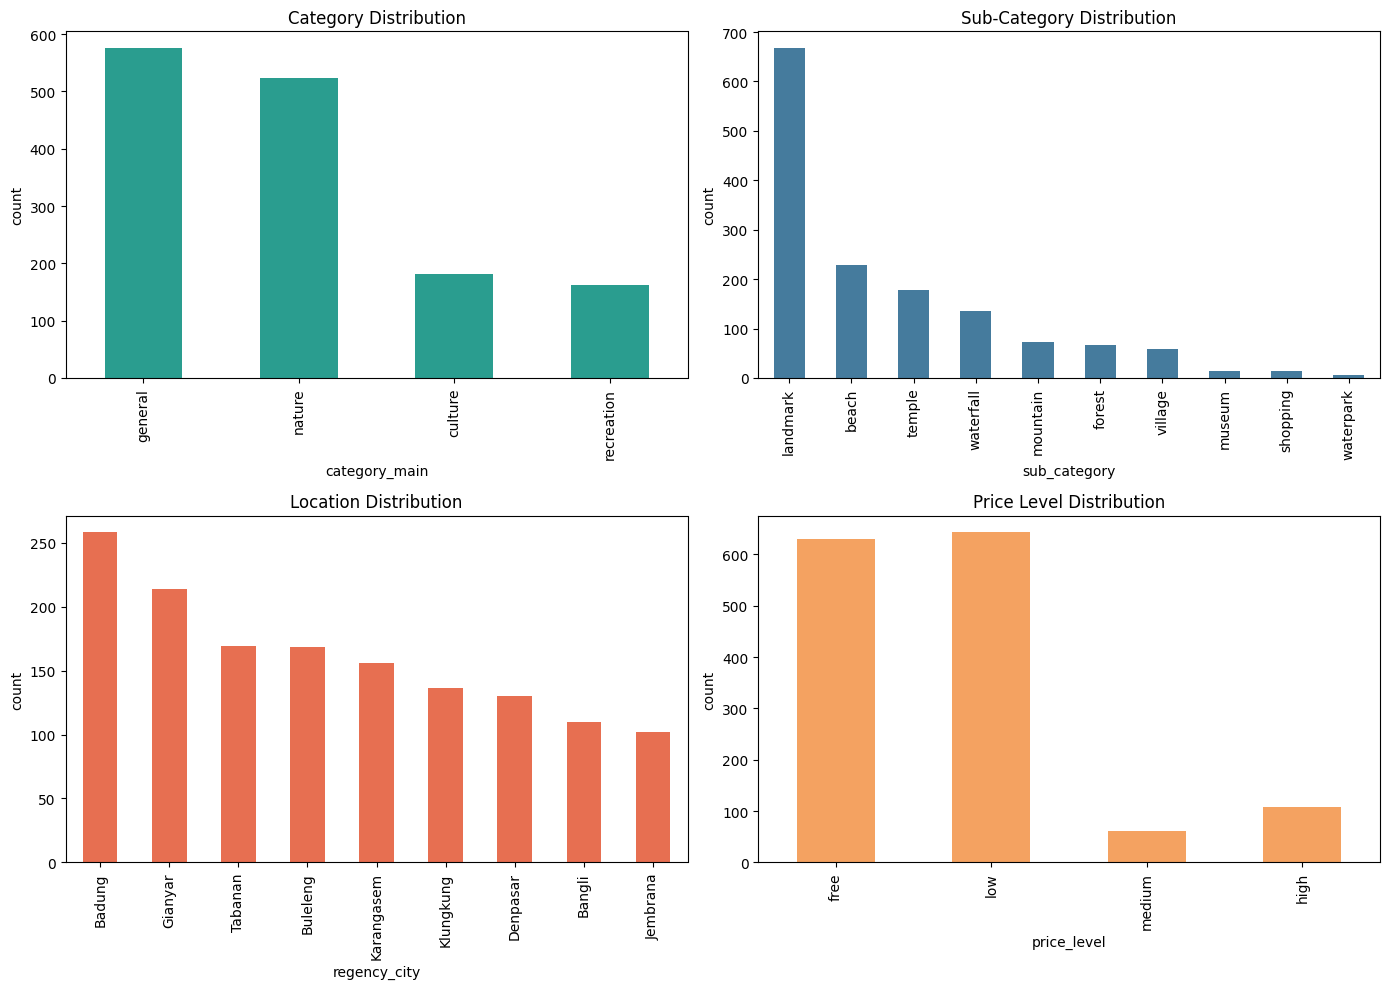

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

final_df["category_main"].value_counts().plot(kind="bar", ax=axes[0, 0], color="#2a9d8f")
axes[0, 0].set_title("Category Distribution")
axes[0, 0].set_xlabel("category_main")
axes[0, 0].set_ylabel("count")

final_df["sub_category"].value_counts().plot(kind="bar", ax=axes[0, 1], color="#457b9d")
axes[0, 1].set_title("Sub-Category Distribution")
axes[0, 1].set_xlabel("sub_category")
axes[0, 1].set_ylabel("count")

final_df["regency_city"].value_counts().plot(kind="bar", ax=axes[1, 0], color="#e76f51")
axes[1, 0].set_title("Location Distribution")
axes[1, 0].set_xlabel("regency_city")
axes[1, 0].set_ylabel("count")

final_df["price_level"].value_counts().reindex(["free", "low", "medium", "high"]).plot(kind="bar", ax=axes[1, 1], color="#f4a261")
axes[1, 1].set_title("Price Level Distribution")
axes[1, 1].set_xlabel("price_level")
axes[1, 1].set_ylabel("count")

plt.tight_layout()
plt.show()

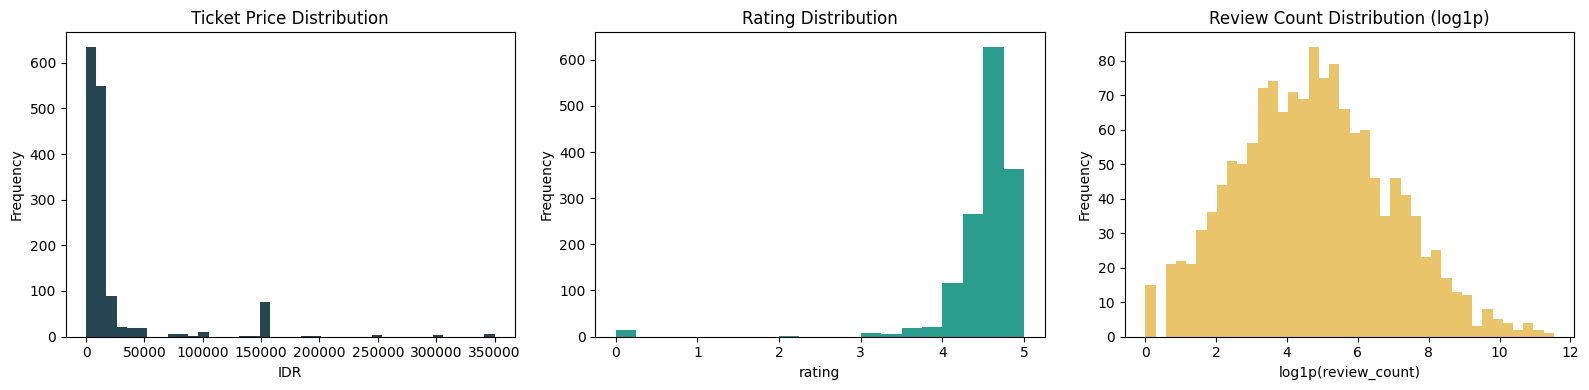

,metric,value
0,price_outliers_iqr,170
1,review_count_outliers_iqr,216


,destination_id,name,regency_city,estimated_ticket_price,rating,review_count
63,DEST-064,Bali Dolphin interaction,Denpasar,350000,3.4,179
87,DEST-088,Bali Exotic Marine Park,Denpasar,350000,4.5,1105
233,DEST-234,Waterbom Bali,Badung,350000,4.7,17726
985,DEST-980,Jeep in mount batur,Bangli,350000,4.9,14
1004,DEST-999,YOLO JEEP AND TREKKING,Bangli,350000,4.9,12
972,DEST-967,Jeep sunrise tour,Bangli,350000,4.3,12
501,DEST-498,Bali ATV n Rafting Adventure,Gianyar,300000,4.9,55
774,DEST-770,Wisata ATV Bali,Tabanan,300000,4.9,30
973,DEST-968,Mount Batur ATV adventure,Bangli,300000,5.0,11
132,DEST-133,Pandora Bali Rafting,Badung,250000,4.8,60


,destination_id,name,regency_city,estimated_ticket_price,rating,review_count
44,DEST-045,Tanah Lot,Denpasar,30000,4.6,101523
234,DEST-235,Taman Budaya Garuda Wisnu Kencana,Badung,150000,4.5,70182
440,DEST-437,Mandala Suci Wenara Wana,Gianyar,90000,4.5,57613
467,DEST-464,Tegallalang Rice Terrace,Gianyar,25000,4.4,52316
218,DEST-219,Pura Luhur Uluwatu,Badung,40000,4.6,50742
296,DEST-296,Pura Ulun Danu Beratan Bedugul,Badung,30000,4.6,49969
201,DEST-202,Pantai Pandawa,Badung,15000,4.6,44808
250,DEST-251,Pantai Kuta,Badung,0,4.5,42383
434,DEST-432,Tegenungan Waterfall,Gianyar,30000,4.4,36933
340,DEST-340,Desa Wisata Penglipuran,Badung,25000,4.8,29898


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

final_df["estimated_ticket_price"].plot(kind="hist", bins=40, ax=axes[0], color="#264653")
axes[0].set_title("Ticket Price Distribution")
axes[0].set_xlabel("IDR")

final_df["rating"].plot(kind="hist", bins=20, ax=axes[1], color="#2a9d8f")
axes[1].set_title("Rating Distribution")
axes[1].set_xlabel("rating")

np.log1p(final_df["review_count"]).plot(kind="hist", bins=40, ax=axes[2], color="#e9c46a")
axes[2].set_title("Review Count Distribution (log1p)")
axes[2].set_xlabel("log1p(review_count)")

plt.tight_layout()
plt.show()

price_q1, price_q3 = final_df["estimated_ticket_price"].quantile([0.25, 0.75])
price_iqr = price_q3 - price_q1
price_outliers = final_df[final_df["estimated_ticket_price"] > price_q3 + 1.5 * price_iqr]

review_q1, review_q3 = final_df["review_count"].quantile([0.25, 0.75])
review_iqr = review_q3 - review_q1
review_outliers = final_df[final_df["review_count"] > review_q3 + 1.5 * review_iqr]

display(pd.DataFrame({"metric": ["price_outliers_iqr", "review_count_outliers_iqr"], "value": [len(price_outliers), len(review_outliers)]}))
display(price_outliers[["destination_id", "name", "regency_city", "estimated_ticket_price", "rating", "review_count"]].sort_values("estimated_ticket_price", ascending=False).head(10))
display(review_outliers[["destination_id", "name", "regency_city", "estimated_ticket_price", "rating", "review_count"]].sort_values("review_count", ascending=False).head(10))

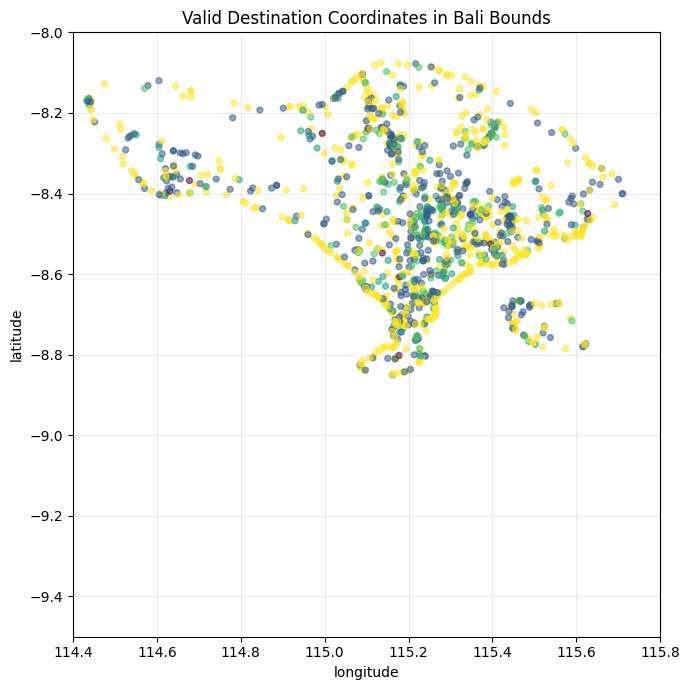

,metric,value
0,valid_coordinates,1436
1,invalid_or_missing_coordinates,7


,destination_id,name,regency_city,latitude,longitude,recommendation_eligible
661,DEST-658,Goa Selomangleng,Tabanan,NaN,NaN,False
670,DEST-667,Taman Wisata Tirtoyoso Park,Tabanan,NaN,NaN,False
673,DEST-670,Air Terjun Dolo,Tabanan,NaN,NaN,False
678,DEST-675,Gumul Paradise Island,Tabanan,NaN,NaN,False
682,DEST-679,Taman Hutan Joyoboyo Kediri,Tabanan,NaN,NaN,False
684,DEST-681,Wisata Sempu Exotic Park,Tabanan,NaN,NaN,False
688,DEST-685,Air Terjun Irenggolo,Tabanan,NaN,NaN,False


In [9]:
valid_coords_df = final_df[final_df["has_coordinates"]].copy()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(valid_coords_df["longitude"], valid_coords_df["latitude"], s=18, alpha=0.55, c=valid_coords_df["data_quality_score"], cmap="viridis")
ax.set_title("Valid Destination Coordinates in Bali Bounds")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_xlim(BALI_LON_MIN, BALI_LON_MAX)
ax.set_ylim(BALI_LAT_MIN, BALI_LAT_MAX)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

display(pd.DataFrame({"metric": ["valid_coordinates", "invalid_or_missing_coordinates"], "value": [len(valid_coords_df), int((~final_df["has_coordinates"]).sum())]}))
display(final_df.loc[~final_df["has_coordinates"], ["destination_id", "name", "regency_city", "latitude", "longitude", "recommendation_eligible"]].head(20))

## 7. Validation Assertions

Bagian ini berfungsi sebagai validasi kualitas dataset secara programatis. Assertion memastikan kolom processed dan final sesuai kontrak, field wajib tidak kosong, harga/rating/review berada dalam range valid, kategori/sub-kategori memakai daftar yang didukung aplikasi, tidak ada duplikat normalized, dan semua destinasi eligible memiliki koordinat valid di Bali.

In [10]:
assert list(processed_df.columns) == PROCESSED_COLUMNS, "Processed columns do not match the dataset contract."
assert list(final_df.columns) == FINAL_COLUMNS, "Final columns do not match the dataset contract."

required_non_null = [
    "destination_id",
    "name",
    "category_raw",
    "category_main",
    "sub_category",
    "regency_city",
    "estimated_ticket_price",
    "is_free",
    "price_level",
    "rating",
    "review_count",
    "has_coordinates",
    "has_description",
    "data_quality_score",
]
assert processed_df[required_non_null].notna().all().all(), "A required processed field contains null values."

assert processed_df["estimated_ticket_price"].ge(0).all(), "Ticket price must be non-negative."
assert processed_df["rating"].between(0.0, 5.0).all(), "Rating must be between 0.0 and 5.0."
assert processed_df["review_count"].ge(0).all(), "Review count must be non-negative."
assert processed_df["data_quality_score"].between(0.0, 1.0).all(), "Quality score must be between 0.0 and 1.0."
assert processed_df["category_main"].isin(SUPPORTED_CATEGORIES).all(), "Unsupported category_main found."
assert processed_df["sub_category"].isin(SUPPORTED_SUB_CATEGORIES).all(), "Unsupported sub_category found."
assert processed_df["price_level"].isin(["free", "low", "medium", "high"]).all(), "Unsupported price_level found."

processed_dup_keys = processed_df["name"].map(normalize_key) + "|" + processed_df["regency_city"].map(normalize_key)
assert not processed_dup_keys.duplicated().any(), "Duplicate normalized name + regency_city keys remain."

eligible_df = final_df[final_df["recommendation_eligible"]]
assert eligible_df["has_coordinates"].all(), "Eligible rows must have coordinates."
assert eligible_df["latitude"].between(BALI_LAT_MIN, BALI_LAT_MAX).all(), "Eligible rows must have valid Bali latitude."
assert eligible_df["longitude"].between(BALI_LON_MIN, BALI_LON_MAX).all(), "Eligible rows must have valid Bali longitude."
assert final_df["popularity_score"].between(0.0, 1.0).all(), "Popularity score must be between 0.0 and 1.0."
assert final_df["content_text"].str.len().gt(0).all(), "content_text must not be empty."

print("All validation checks passed.")

All validation checks passed.


## 8. Save Processed and Final CSV Outputs

Bagian ini menyimpan artefak hasil notebook. `processed_df` menjadi clean dataset v1 di `data/processed/bali_destinations.csv`, sedangkan `final_df` menjadi dataset model-ready awal di `data/final/bali_destinations.csv`. Kedua folder sudah di-ignore oleh git, sehingga output lokal tidak otomatis masuk commit.

In [11]:
processed_df.to_csv(PROCESSED_PATH, index=False)
final_df.to_csv(FINAL_PATH, index=False)

saved_summary = pd.DataFrame(
    {
        "artifact": ["processed_csv", "final_csv"],
        "path": [str(PROCESSED_PATH), str(FINAL_PATH)],
        "rows": [len(processed_df), len(final_df)],
        "columns": [processed_df.shape[1], final_df.shape[1]],
        "exists": [PROCESSED_PATH.exists(), FINAL_PATH.exists()],
    }
)

display(saved_summary)

,artifact,path,rows,columns,exists
0,processed_csv,d:\Pijak\balinavi-smart-travel\data\processed\...,1443,23,True
1,final_csv,d:\Pijak\balinavi-smart-travel\data\final\bali...,1443,27,True


## 9. Findings, Data Quality Issues, and Pipeline Notes

Bagian ini merangkum temuan utama dan daftar issue kualitas data yang perlu diketahui sebelum logic notebook dipindahkan ke pipeline `src/`.

### Ringkasan temuan

- Dataset raw sudah cukup lengkap untuk MVP: nama, kategori utama, lokasi, harga, rating, review, koordinat, maps URL, dan image URL tersedia.
- Dataset raw tidak memiliki `description`, `tags`, dan `activity`; field tersebut diisi `null`, sehingga `content_text` sementara bertumpu pada nama, kategori, sub-kategori hasil inferensi, dan lokasi.
- `sub_category` di-infer dari kata kunci nama destinasi lebih dulu, lalu fallback ke aturan kontrak jika tidak ada sinyal kata kunci.
- Koordinat di luar batas Bali diset `NaN`, sehingga baris tersebut tetap tersimpan tetapi tidak eligible untuk rekomendasi.

### Daftar issue kualitas data

- Terdapat 9 duplikat berdasarkan kombinasi normalized `name + regency_city`; notebook menghapus duplikat dan mempertahankan baris dengan kelengkapan data terbaik.
- Terdapat 4 `image_url` kosong pada raw dataset; nilai tersebut dinormalisasi menjadi `null`.
- Terdapat 7 koordinat di luar batas Bali; koordinat tersebut diset `NaN` dan destinasi terkait tidak eligible untuk rekomendasi.
- Semua `detail_category`, `description`, `tags`, dan `activity` kosong karena tidak tersedia di raw dataset; ini membatasi kekayaan `content_text` untuk model awal.
- Banyak destinasi masuk kategori `general` karena raw kategori `Umum`; kategori ini valid untuk MVP tetapi kurang informatif untuk ranking rekomendasi.
- Deteksi outlier menemukan harga dan jumlah review yang sangat tinggi; notebook belum menghapus outlier karena nilai tersebut masih mungkin valid secara domain dan perlu review manual.

### Content text enrichment (Improvement)

- `content_text` diperkaya dengan 5 jenis enrichment untuk meningkatkan discriminative power TF-IDF:
  1. **Keyword enrichment per sub_category**: setiap sub-kategori mendapat 6-8 keyword domain (misal beach → pantai, ombak, surfing, snorkeling, dll).
  2. **Price signal tokens**: `price_level` dan `is_free` di-encode sebagai token teks (gratis, murah, harga_premium, dll).
  3. **Rating/popularity tokens**: rating bucket dan review count tier di-encode sebagai keyword (rating_tinggi, banyak_ulasan, dll).
  4. **Name normalization**: tanda baca dan noise (parkir, tiket) dihapus dari nama destinasi.
  5. **Geographic region tokens**: koordinat di-encode sebagai area Bali (bali_utara, bali_selatan, bali_barat, dll).
- Enrichment ini meningkatkan rata-rata token per destinasi dari ~7.5 menjadi ~20+ token, sehingga TF-IDF bisa membedakan destinasi secara lebih bermakna.
- Tanpa enrichment, ~5.968 pasangan destinasi memiliki cosine similarity = 1.0 (dianggap identik oleh model).

### Catatan implementasi pipeline

- Notebook ini dapat menjadi referensi implementasi berikutnya di `src/preprocessing/preprocess.py` dan `src/features/build_features.py`.
- Fungsi enrichment (`SUBCATEGORY_KEYWORDS`, `price_text_tokens`, `rating_text_tokens`, `normalize_name_for_content`, `bali_region_tokens`) harus dipindahkan ke `src/features/build_features.py`.